How do international trade shocks impact firm performance across industries?

In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as sm

In [23]:
df1 = pd.read_csv("/content/drive/MyDrive/Canada_Economic_Impact/Trade Shock on Firm Performance - Iqbal/Master_Revenue_30K_5M_2013_2023.csv")
df2 = pd.read_csv("/content/drive/MyDrive/Canada_Economic_Impact/Trade Shock on Firm Performance - Iqbal/Master_Revenue_5M_20M_2013_2023.csv")
trade = pd.read_csv("/content/drive/MyDrive/Canada_Economic_Impact/Trade Shock on Firm Performance - Iqbal/trade.csv")
gdp = pd.read_csv("/content/drive/MyDrive/Canada_Economic_Impact/Trade Shock on Firm Performance - Iqbal/gdp.csv")
naics = pd.read_csv("/content/drive/MyDrive/Canada_Economic_Impact/Trade Shock on Firm Performance - Iqbal/Master_NAICS_General_2013_2023.csv")

print(df1.shape, df2.shape, trade.shape, gdp.shape, naics.shape)

(782537, 33) (11361, 33) (2029, 8) (3003, 4) (26355, 3)


In [24]:
df = pd.concat([df1, df2], ignore_index=True)

In [25]:
df.head()

,Year,Naics code,Description_English,Province,Province_Description,Incorporation Status,Bottom quartile All other revenue,Bottom quartile High revenue range,Bottom quartile Low revenue range,Bottom quartile Sales of goods and services,...,Upper middle All other revenue,Upper middle High revenue range,Upper middle Low revenue range,Upper middle Sales of goods and services,Upper middle Total revenue,Whole industry All other revenue,Whole industry High revenue range,Whole industry Sales of goods and services,Whole industry Total revenue,Whole industry low revenue range
0,2013,11,"Agriculture, Forestry, Fishing and Hunting",0.0,Canada Total,1,NaN,43.0,30.0,NaN,...,NaN,106.0,65.0,NaN,82.7,NaN,5000.0,NaN,101.1,30.0
1,2013,11,"Agriculture, Forestry, Fishing and Hunting",0.0,Canada Total,1,20.3,162.0,30.0,65.3,...,55.5,954.0,432.0,598.0,653.5,61.9,5000.0,669.9,731.8,30.0
2,2013,11,"Agriculture, Forestry, Fishing and Hunting",0.0,Canada Total,1,NaN,78.0,30.0,NaN,...,NaN,705.0,238.0,NaN,437.1,NaN,5000.0,NaN,560.1,30.0
3,2013,11,"Agriculture, Forestry, Fishing and Hunting",10.0,Newfoundland and Labrador,1,NaN,37.0,30.0,NaN,...,NaN,72.0,49.0,NaN,58.9,NaN,5000.0,NaN,69.8,30.0
4,2013,11,"Agriculture, Forestry, Fishing and Hunting",10.0,Newfoundland and Labrador,1,7.6,157.0,30.0,78.4,...,12.8,644.0,350.0,468.6,481.4,27.7,5000.0,544.5,572.2,30.0


In [26]:
df.shape

(793898, 33)

In [27]:
trade.head()

,Province,industry,REF_DATE,total_trade,Value of exports,Value of imports,GDP,trade_pct_gdp
0,Alberta,0,2013,139364164.0,92750112.0,46614052.0,310713,44.853020
1,Alberta,0,2014,153658120.0,103631865.0,50026255.0,328652,46.754050
2,Alberta,0,2015,120889390.0,79154756.0,41734634.0,317182,38.113572
3,Alberta,0,2016,104104281.0,64621025.0,39483256.0,306203,33.998452
4,Alberta,0,2017,125464737.0,85402212.0,40062525.0,319212,39.304518


In [28]:
y_col = "Whole industry Total revenue"

df = df[["Year", "Naics code", y_col]].copy()
df = df.rename(columns={"Year":"year", "Naics code":"naics_code", y_col:"total_revenue"})

df["total_revenue"] = pd.to_numeric(df["total_revenue"], errors="coerce")
df = df.dropna(subset=["year", "naics_code", "total_revenue"])

df["log_rev"] = np.log(df["total_revenue"])
df.head()

,year,naics_code,total_revenue,log_rev
0,2013,11,101.1,4.616110
1,2013,11,731.8,6.595507
2,2013,11,560.1,6.328115
3,2013,11,69.8,4.245634
4,2013,11,572.2,6.349489


In [29]:
df["naics_code"] = df["naics_code"].astype(int)

df["naics2"] = df["naics_code"].astype(str).str.zfill(2).str[:2].astype(int)

def map_to_trade_sector(n2: int) -> int:
    if n2 in (31, 32, 33):
        return 31
    if n2 in (44, 45):
        return 44
    if n2 in (48, 49):
        return 48
    return n2

df["trade_sector"] = df["naics2"].apply(map_to_trade_sector)
df[["naics_code","naics2","trade_sector"]].head(10)

,naics_code,naics2,trade_sector
0,11,11,11
1,11,11,11
2,11,11,11
3,11,11,11
4,11,11,11
5,11,11,11
6,11,11,11
7,11,11,11
8,11,11,11
9,11,11,11


In [30]:
for c in ["total_trade", "Value of exports", "Value of imports", "GDP"]:
    trade[c] = pd.to_numeric(trade[c], errors="coerce")

trade = trade.rename(columns={"REF_DATE":"year", "industry":"trade_sector"})

trade_can = (
    trade.groupby(["trade_sector","year"], as_index=False)[
        ["total_trade","Value of exports","Value of imports","GDP"]
    ].sum()
)

trade_can.head(10)

,trade_sector,year,total_trade,Value of exports,Value of imports,GDP
0,0,2013,7.348957e+08,324308623.0,410587028.0,1826384
1,0,2014,8.089174e+08,363727680.0,445189719.0,1878121
2,0,2015,8.216855e+08,359274710.0,462410807.0,1895169
3,0,2016,8.100246e+08,350070812.0,459953749.0,1915144
4,0,2017,8.538157e+08,366953987.0,486861731.0,1974400
5,0,2018,9.039596e+08,391719541.0,512240043.0,2031281
6,0,2019,9.090822e+08,393843891.0,515238281.0,2072218
7,0,2020,8.158846e+08,348472234.0,467412351.0,1970578
8,0,2021,9.404403e+08,411985178.0,528455130.0,2087708
9,0,2022,1.155899e+09,518146889.0,637751729.0,2186038


In [31]:
df_trade = trade_can.copy()

# Net trade exposure: (exports - imports)/GDP
df_trade["net_trade_exposure"] = (df_trade["Value of exports"] - df_trade["Value of imports"]) / df_trade["GDP"]

# Trade shock: year-over-year log change in total trade
df_trade = df_trade.sort_values(["trade_sector","year"])
df_trade["trade_shock"] = np.log(df_trade["total_trade"]).diff()

df_trade["trade_shock"] = df_trade.groupby("trade_sector")["total_trade"].transform(lambda s: np.log(s).diff())

df_trade.head(12)

,trade_sector,year,total_trade,Value of exports,Value of imports,GDP,net_trade_exposure,trade_shock
0,0,2013,7.348957e+08,324308623.0,410587028.0,1826384,-47.240014,NaN
1,0,2014,8.089174e+08,363727680.0,445189719.0,1878121,-43.374223,0.095968
2,0,2015,8.216855e+08,359274710.0,462410807.0,1895169,-54.420528,0.015661
3,0,2016,8.100246e+08,350070812.0,459953749.0,1915144,-57.375809,-0.014293
4,0,2017,8.538157e+08,366953987.0,486861731.0,1974400,-60.731232,0.052651
5,0,2018,9.039596e+08,391719541.0,512240043.0,2031281,-59.332265,0.057069
6,0,2019,9.090822e+08,393843891.0,515238281.0,2072218,-58.581863,0.005651
7,0,2020,8.158846e+08,348472234.0,467412351.0,1970578,-60.357985,-0.108163
8,0,2021,9.404403e+08,411985178.0,528455130.0,2087708,-55.788430,0.142075
9,0,2022,1.155899e+09,518146889.0,637751729.0,2186038,-54.713065,0.206285


In [32]:
df = df.merge(df_trade[["trade_sector","year","net_trade_exposure","trade_shock"]],
                  on=["trade_sector","year"],
                  how="left")

df = df.dropna(subset=["net_trade_exposure","trade_shock","log_rev"])

df.shape, df.head()

((720478, 8),
        year  naics_code  total_revenue   log_rev  naics2  trade_sector  \
 72386  2014          11          107.7  4.679350      11            11   
 72387  2014          11          744.4  6.612579      11            11   
 72388  2014          11          564.1  6.335232      11            11   
 72389  2014          11           75.5  4.324133      11            11   
 72390  2014          11          618.1  6.426650      11            11   
 
        net_trade_exposure  trade_shock  
 72386           25.249633    -0.097852  
 72387           25.249633    -0.097852  
 72388           25.249633    -0.097852  
 72389           25.249633    -0.097852  
 72390           25.249633    -0.097852  )

In [33]:
model = sm.ols(
    "log_rev ~ trade_shock + net_trade_exposure + C(trade_sector) + C(year)",
    data=df
).fit(cov_type="cluster", cov_kwds={"groups": df["trade_sector"]})

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                log_rev   R-squared:                       0.069
Model:                            OLS   Adj. R-squared:                  0.069
Method:                 Least Squares   F-statistic:                     159.5
Date:                Sun, 14 Dec 2025   Prob (F-statistic):           1.34e-15
Time:                        06:05:46   Log-Likelihood:            -1.7551e+06
No. Observations:              720478   AIC:                         3.510e+06
Df Residuals:                  720448   BIC:                         3.511e+06
Df Model:                          29                                         
Covariance Type:              cluster                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 8.86

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 29, but rank is 11
  warnings.warn('covariance of constraints does not have full '


In [34]:
df = df.sort_values(["naics_code","year"])
df["rev_growth"] = df.groupby("naics_code")["log_rev"].diff()

df_g = df.dropna(subset=["rev_growth","trade_shock","net_trade_exposure"])

model_g = sm.ols(
    "rev_growth ~ trade_shock + net_trade_exposure + C(trade_sector) + C(year)",
    data=df_g
).fit(cov_type="cluster", cov_kwds={"groups": df_g["trade_sector"]})

print(model_g.summary())

                            OLS Regression Results                            
Dep. Variable:             rev_growth   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     514.2
Date:                Sun, 14 Dec 2025   Prob (F-statistic):           3.51e-19
Time:                        06:06:01   Log-Likelihood:            -1.7293e+06
No. Observations:              718372   AIC:                         3.459e+06
Df Residuals:                  718343   BIC:                         3.459e+06
Df Model:                          28                                         
Covariance Type:              cluster                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 0.10

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 28, but rank is 11
  warnings.warn('covariance of constraints does not have full '


In [35]:
high_shock = df["trade_shock"].quantile(0.8)
low_shock  = df["trade_shock"].quantile(0.2)

df["shock_regime"] = np.where(df["trade_shock"] >= high_shock, "Positive Shock",
                       np.where(df["trade_shock"] <= low_shock,  "Negative Shock",
                                "Normal"))

df["shock_regime"].value_counts()

,count
shock_regime,
Normal,426078
Positive Shock,147805
Negative Shock,146595


In [48]:
table1 = (
    df[df["shock_regime"] != "Normal"]
    .groupby("shock_regime")["rev_growth"]
    .agg(mean="mean", median="median", std="std", count="count")
    .reset_index()
)

table1 = table1.style.format({
    "mean": "{:.2%}",
    "std": "{:.2%}",
})

table1

,shock_regime,mean,median,std,count
0,Negative Shock,0.72%,0.000000,270.59%,146396
1,Positive Shock,1.48%,0.000000,266.28%,147323


In [37]:
sector_lookup = {
    11: "Agriculture, Forestry, Fishing and Hunting",
    21: "Mining, Quarrying, and Oil and Gas Extraction",
    22: "Utilities",
    23: "Construction",
    31: "Manufacturing",
    41: "Wholesale Trade",
    44: "Retail Trade",
    48: "Transportation and Warehousing",
    51: "Information and Cultural Industries",
    53: "Real Estate and Rental and Leasing",
    54: "Professional, Scientific and Technical Services",
    55: "Management of Companies and Enterprises",
    56: "Administrative and Support Services",
    61: "Educational Services",
    62: "Health Care and Social Assistance",
    71: "Arts, Entertainment and Recreation",
    72: "Accommodation and Food Services",
    81: "Other Services (except Public Administration)"
}

In [42]:
table2 = (
    df[df["shock_regime"] == "Negative Shock"]
    .groupby("trade_sector")["rev_growth"]
    .mean()
    .reset_index(name="mean_rev_growth")
    .sort_values("mean_rev_growth")
)

table2["sector_name"] = table2["trade_sector"].map(sector_lookup)

table2 = table2.dropna(subset=["sector_name"])

table2

,trade_sector,mean_rev_growth,sector_name
15,62,-0.003604,Health Care and Social Assistance
2,21,-0.003005,"Mining, Quarrying, and Oil and Gas Extraction"
12,55,-0.002541,Management of Companies and Enterprises
6,41,-0.001384,Wholesale Trade
7,44,-0.000844,Retail Trade
14,61,-0.000253,Educational Services
4,23,-0.000020,Construction
11,54,0.001755,"Professional, Scientific and Technical Services"
18,81,0.001947,Other Services (except Public Administration)
17,72,0.002480,Accommodation and Food Services


In [43]:
trade_can["net_trade_exposure"] = (
    (trade_can["Value of exports"] - trade_can["Value of imports"]) / trade_can["GDP"]
)

In [44]:
exposure_df = (
    trade_can.groupby("trade_sector", as_index=False)["net_trade_exposure"]
    .mean()
    .rename(columns={"net_trade_exposure": "avg_net_exposure"})
)

In [45]:
exposure_df["sector_name"] = exposure_df["trade_sector"].map(sector_lookup)
exposure_df = exposure_df.dropna(subset=["sector_name"])

In [46]:
exposure_df = exposure_df.sort_values("avg_net_exposure", key=lambda s: s.abs(), ascending=False)

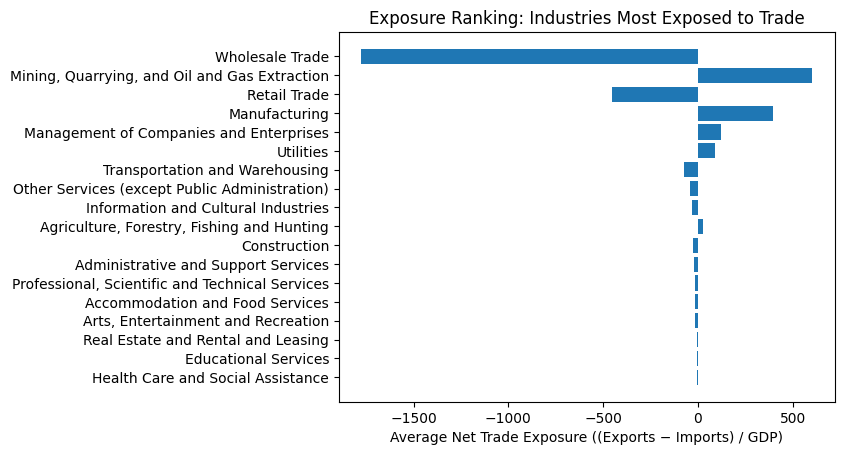

In [47]:
plt.figure()
plt.barh(exposure_df["sector_name"], exposure_df["avg_net_exposure"])
plt.xlabel("Average Net Trade Exposure ((Exports − Imports) / GDP)")
plt.title("Exposure Ranking: Industries Most Exposed to Trade")
plt.gca().invert_yaxis()
plt.show()